In [1]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os
import copy
import pandas as pd
from tqdm import tqdm
from filter_extinction import ext_utils
import pdb

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /Users/mhuston/NotBacked/spisea_data/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
%load_ext autoreload
%autoreload 2

# Set up the ExtinctionCoefficientFitter
First, the fitter object will generate or load a grid of stellar colors and extinctions

In [3]:
roman_filters = ['roman,wfi,f062','roman,wfi,f087','roman,wfi,f106','roman,wfi,f129',
             'roman,wfi,f158','roman,wfi,f184','roman,wfi,f213','roman,wfi,f146']
ecf=0
# Compute extinction for all of Roman's filters, and exclude F146 from the color set
# This will use these defaults: A_Ks range of 0-5, [Fe/H]=0.0, and logg=[4.5, 2.0]
# If you change the A_Ks grid spacing, logg values, or filter sets, set recompute=True
ecf = ext_utils.ExtinctionCoefficientFitter(color_filter_list=roman_filters,
                                            ext_only_filter_list = ['euclid,vis'],
                                            #recompute_grid=True,
                                           )

For roman,wfi,f062, m_ab - m_vega = 0.1418860315199808
For roman,wfi,f087, m_ab - m_vega = 0.5069624249565408
For roman,wfi,f106, m_ab - m_vega = 0.6659690376827427
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f184, m_ab - m_vega = 1.5764881750217157
For roman,wfi,f213, m_ab - m_vega = 1.8314297601129965
For roman,wfi,f146, m_ab - m_vega = 0.9703680920347395
For euclid,vis, m_ab - m_vega = 0.2563127244158494
Load or generate extinction + colors grid
Found saved file ./grids/ext_grid_met_0.00_AKs_5.00.h5


# The fitting process
Next, we can use the computed grid to fit extinction in one filter to a polynomial of custom order of A_Ks and selected filter color(s). Polynomial cross terms are used for each color to A_Ks but not among different colors.

For different applications, it may be optimal to use different colors to estimate the extinction in a certain filter. We explore a few options for this.

# Ideal scenario: all filters
Let's fit the extinction function for each filter. For the bluest and reddest filters, we use the filter and its neighboring filter to use a single color. For middle standard filters, we use two colors, pairing the filter with each neighbor. For the F146 wide filter, we use 3 colors, incorporating all 4 standard filters it encompasses.

The GBTDS includes snapshots in all filters.

This is all we provide for absolute magnitudes, as these are for simulations where one can assume all filters can be simulated.

In [13]:
fits_dict = {}

### F062, using absolute F062-F087 color

In [14]:
ecf.run_fit('f062', ['f062_f087_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

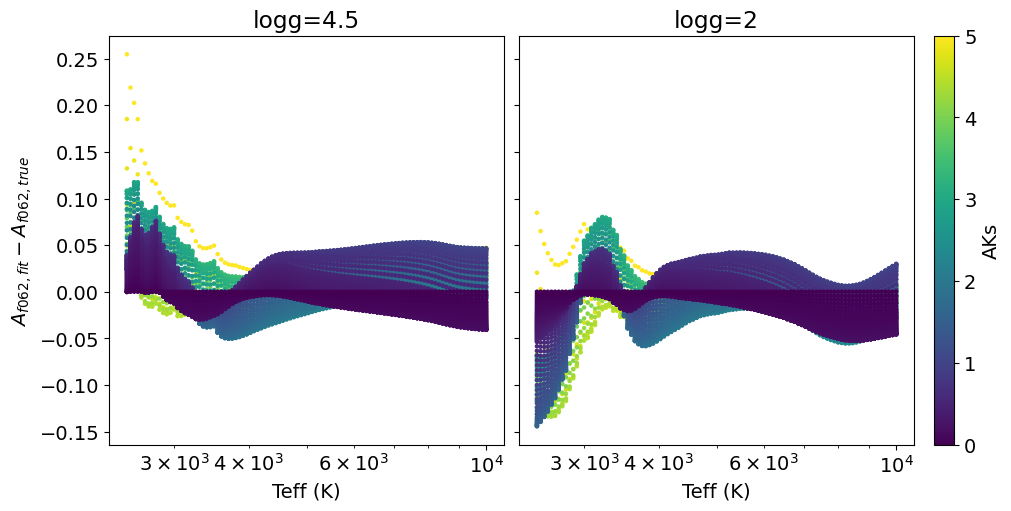

In [15]:
fig,ax = ecf.plot_fit_result()

This is the color that looks the worse in these residuals. We have no bluer filters to better characterize the spectrum shape, and as the bluest filter, it is the most strongly impacted by extinction. High extinction targets will rarely be detectable in this filter, so using a higher quality fit for a more limited A_Ks range may be ideal.

For convenience, we can print the latex code to print the function as an equation and its best fit parameters in a table.

In [16]:
f062_v1_eqn = ecf.print_function_latex()
print(f062_v1_eqn)

\begin{aligned} 
 \frac{A_{f062}}{A_{Ks}} = a_{0} + a_{1} A_{Ks} + a_{2} A_{Ks}^{2} + a_{3} A_{Ks}^{3} + a_{4} A_{Ks}^{4} \\ 
\quad + b_{0} C_{1} + b_{1} C_{1} A_{Ks} + b_{2} C_{1} A_{Ks}^{2} + b_{3} C_{1} A_{Ks}^{3} + b_{4} C_{1}^{2} + b_{5} C_{1}^{2} A_{Ks} + b_{6} C_{1}^{2} A_{Ks}^{2} + b_{7} C_{1}^{3} + b_{8} C_{1}^{3} A_{Ks} + b_{9} C_{1}^{4} 
 \end{aligned}


In [17]:
f062_v1_tab = ecf.print_coeffs_deluxetable()
print(f062_v1_tab)

\begin{deluxetable}{lccc}
\tablecaption{Polynomial Coefficients for f062 Fit}
\tablehead{\colhead{ID} & \colhead{Term} & \colhead{Value} & \colhead{Uncertainty}}
\startdata
$a_{0}$ & $1$ & 14.55020 & 0.00197 \\
$a_{1}$ & $A_{Ks}^{1}$ & -2.22273 & 0.00346 \\
$a_{2}$ & $A_{Ks}^{2}$ & 0.73554 & 0.00212 \\
$a_{3}$ & $A_{Ks}^{3}$ & -0.12366 & 0.00053 \\
$a_{4}$ & $A_{Ks}^{4}$ & 0.00806 & 0.00005 \\
$b_{0}$ & $C_{1}$ & -0.93235 & 0.00240 \\
$b_{1}$ & $C_{1}A_{Ks}$ & 0.45687 & 0.00185 \\
$b_{2}$ & $C_{1}A_{Ks}^{2}$ & -0.09707 & 0.00052 \\
$b_{3}$ & $C_{1}A_{Ks}^{3}$ & 0.00735 & 0.00005 \\
$b_{4}$ & $C_{1}^{2}$ & 0.02969 & 0.00182 \\
$b_{5}$ & $C_{1}^{2}A_{Ks}$ & -0.01585 & 0.00062 \\
$b_{6}$ & $C_{1}^{2}A_{Ks}^{2}$ & 0.00285 & 0.00008 \\
$b_{7}$ & $C_{1}^{3}$ & -0.00385 & 0.00072 \\
$b_{8}$ & $C_{1}^{3}A_{Ks}$ & -0.00178 & 0.00010 \\
$b_{9}$ & $C_{1}^{4}$ & 0.00351 & 0.00011 \\
\enddata
\tablecomments{$C_{1} = \text{f062\_f087\_abs}$}
\end{deluxetable}


### F087, using absolute F062-F087, F087-F106 colors

In [18]:
ecf.run_fit('f087', ['f062_f087_abs', 'f087_f106_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

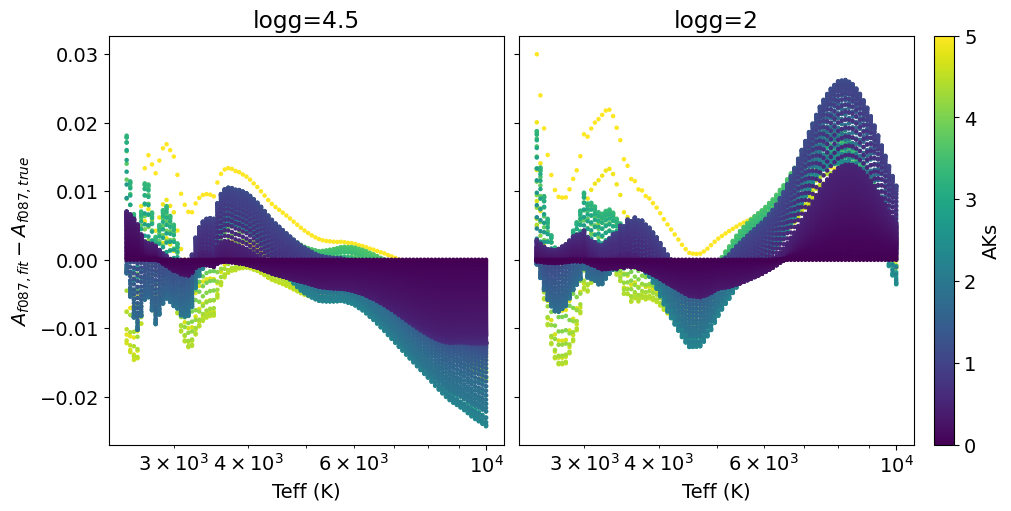

In [19]:
fig,ax = ecf.plot_fit_result()

This one is looking much better, given the two colors and slight red-ward shift.

In [20]:
f087_v1_eqn = ecf.print_function_latex()

In [21]:
f087_v1_tab = ecf.print_coeffs_deluxetable()

### F106, using absolute F087-F106, F106-F129 colors

In [22]:
ecf.run_fit('f106', ['f087_f106_abs', 'f106_f129_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

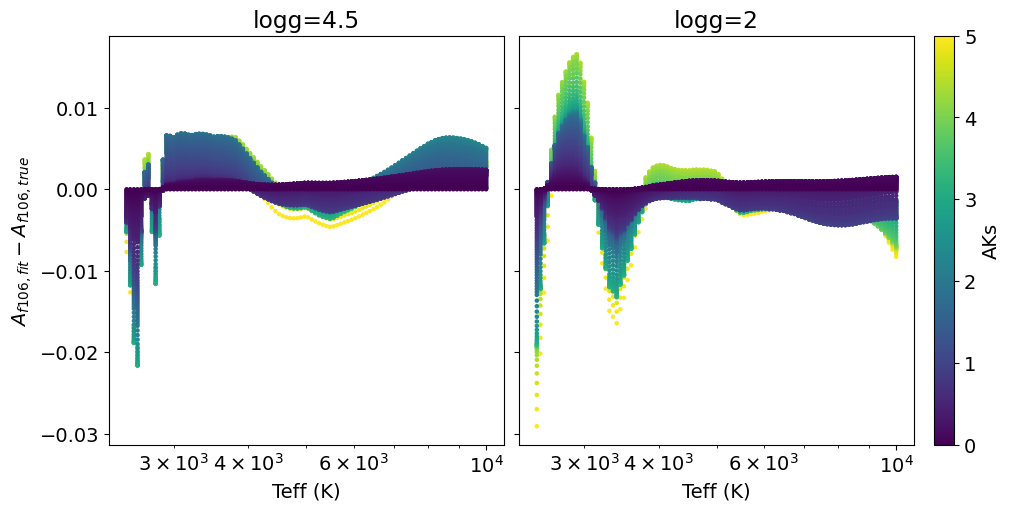

In [23]:
fig,ax = ecf.plot_fit_result()

In [24]:
f106_v1_eqn = ecf.print_function_latex()

In [25]:
f106_v1_tab = ecf.print_coeffs_deluxetable()

### F129, using absolute F106-F129, F129-F158 colors

In [26]:
ecf.run_fit('f129', ['f106_f129_abs', 'f129_f158_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

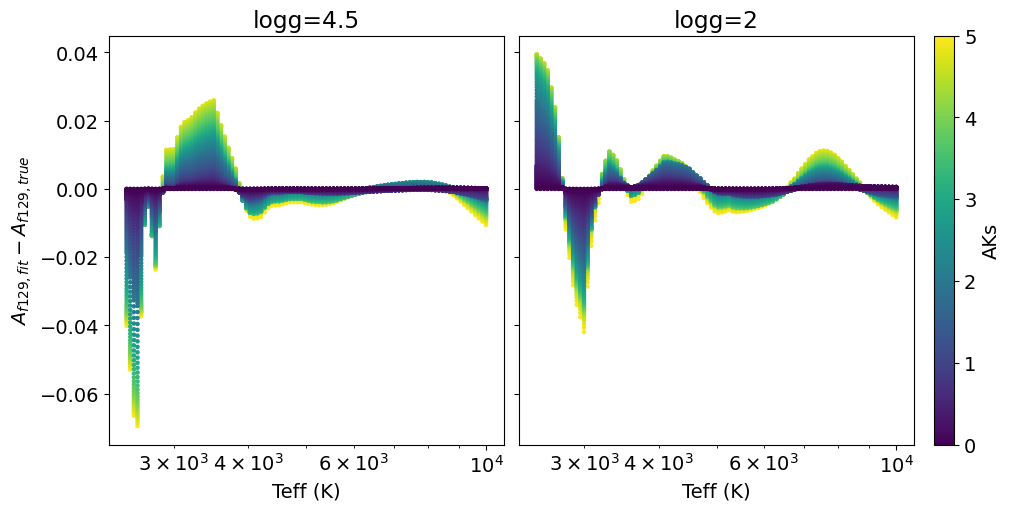

In [27]:
fig,ax = ecf.plot_fit_result()

In [28]:
f129_v1_eqn = ecf.print_function_latex()

In [29]:
f129_v1_tab = ecf.print_coeffs_deluxetable()

### F158, using absolute F129-F158, F158-F184 colors

In [30]:
ecf.run_fit('f158', ['f129_f158_abs', 'f158_f184_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

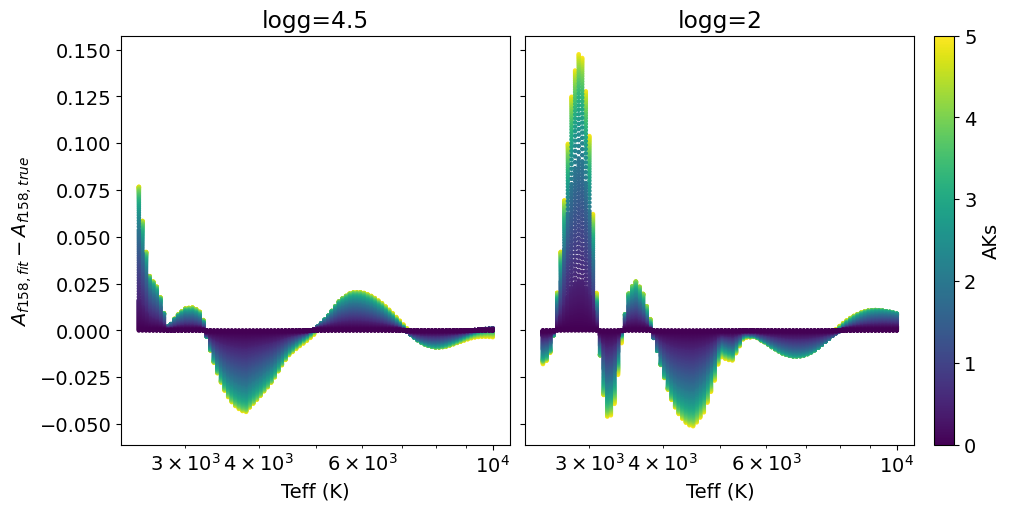

In [31]:
fig,ax = ecf.plot_fit_result()

Notably, performance gets bad here for high extinction, particularly in low temperaure giants.

In [32]:
f158_v1_eqn = ecf.print_function_latex()

In [33]:
f158_v1_tab = ecf.print_coeffs_deluxetable()

### F184, using absolute F158-F184, F184-F213 colors

In [34]:
ecf.run_fit('f184', ['f158_f184_abs', 'f184_f213_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

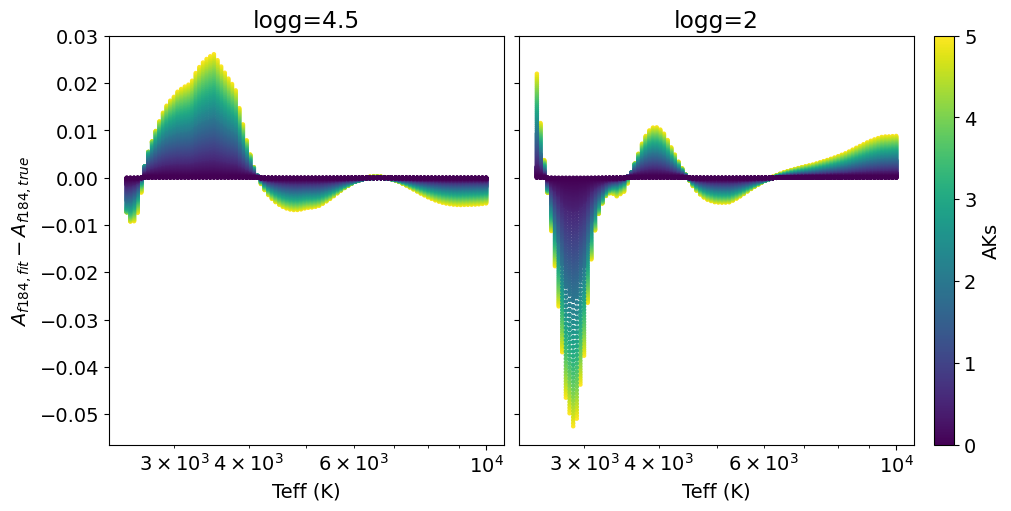

In [35]:
fig,ax = ecf.plot_fit_result()

In [36]:
f184_v1_eqn = ecf.print_function_latex()

In [37]:
f184_v1_tab = ecf.print_coeffs_deluxetable()

### F213, using absolute F184-F213 color

In [38]:
ecf.run_fit('f213', ['f184_f213_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

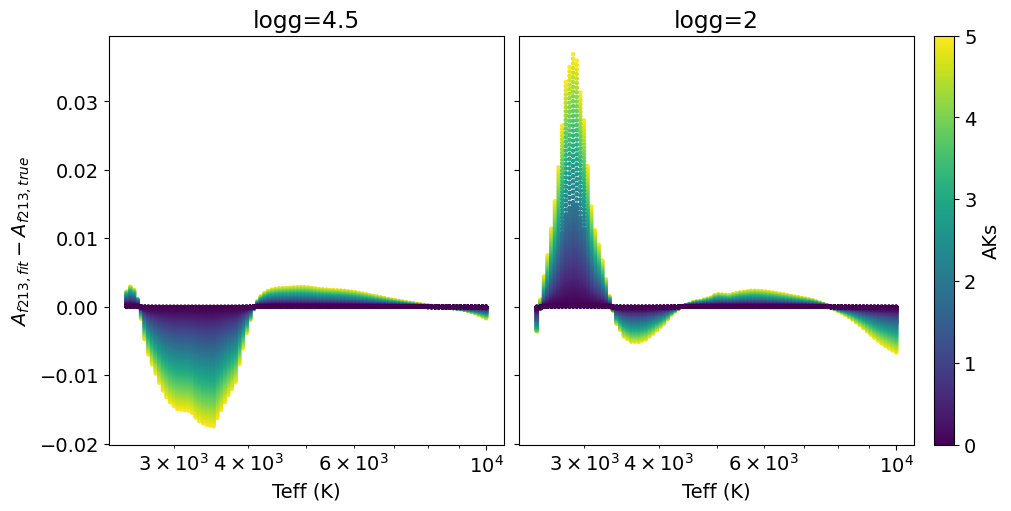

In [39]:
fig,ax = ecf.plot_fit_result()

In [40]:
f213_v1_eqn = ecf.print_function_latex()

In [41]:
f213_v1_tab = ecf.print_coeffs_deluxetable()

### F146 fit, using F106-F129, F129-F158, and F158-F184 colors

In [42]:
ecf.run_fit('f146', ['f106_f129_abs', 'f129_f158_abs', 'f158_f184_abs'], order=4)
fits_dict.update(ecf.get_fit_dict())

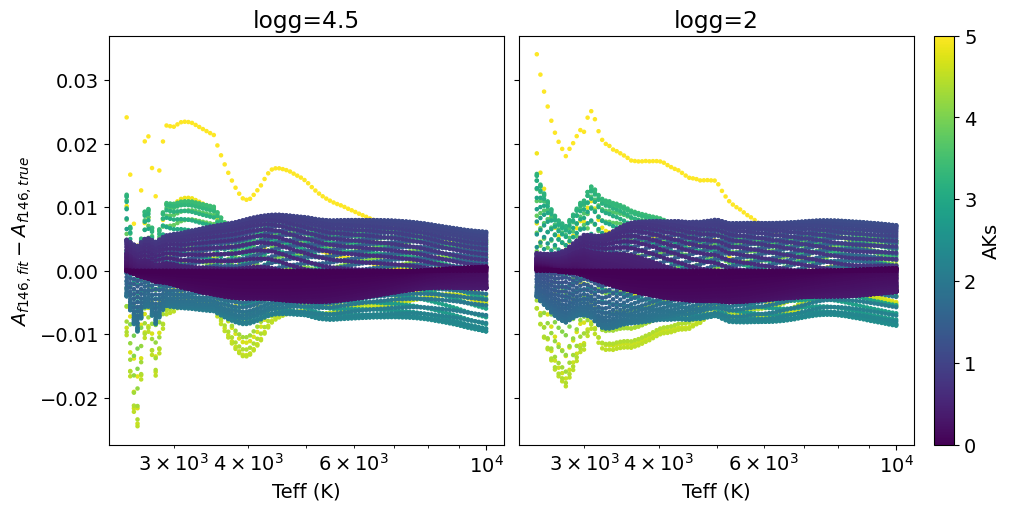

In [43]:
fig,ax = ecf.plot_fit_result()

In [44]:
f146_v1_eqn = ecf.print_function_latex()

In [45]:
print(f146_v1_eqn)

\begin{aligned} 
 \frac{A_{f146}}{A_{Ks}} = a_{0} + a_{1} A_{Ks} + a_{2} A_{Ks}^{2} + a_{3} A_{Ks}^{3} + a_{4} A_{Ks}^{4} \\ 
\quad + b_{0} C_{1} + b_{1} C_{1} A_{Ks} + b_{2} C_{1} A_{Ks}^{2} + b_{3} C_{1} A_{Ks}^{3} + b_{4} C_{1}^{2} + b_{5} C_{1}^{2} A_{Ks} + b_{6} C_{1}^{2} A_{Ks}^{2} + b_{7} C_{1}^{3} + b_{8} C_{1}^{3} A_{Ks} + b_{9} C_{1}^{4} \\ 
\quad + c_{0} C_{2} + c_{1} C_{2} A_{Ks} + c_{2} C_{2} A_{Ks}^{2} + c_{3} C_{2} A_{Ks}^{3} + c_{4} C_{2}^{2} + c_{5} C_{2}^{2} A_{Ks} + c_{6} C_{2}^{2} A_{Ks}^{2} + c_{7} C_{2}^{3} + c_{8} C_{2}^{3} A_{Ks} + c_{9} C_{2}^{4} \\ 
\quad + d_{0} C_{3} + d_{1} C_{3} A_{Ks} + d_{2} C_{3} A_{Ks}^{2} + d_{3} C_{3} A_{Ks}^{3} + d_{4} C_{3}^{2} + d_{5} C_{3}^{2} A_{Ks} + d_{6} C_{3}^{2} A_{Ks}^{2} + d_{7} C_{3}^{3} + d_{8} C_{3}^{3} A_{Ks} + d_{9} C_{3}^{4} 
 \end{aligned}


In [46]:
f146_v1_tab = ecf.print_coeffs_deluxetable()

In [47]:
print(f146_v1_tab)

\begin{deluxetable}{lccc}
\tablecaption{Polynomial Coefficients for f146 Fit}
\tablehead{\colhead{ID} & \colhead{Term} & \colhead{Value} & \colhead{Uncertainty}}
\startdata
$a_{0}$ & $1$ & 3.50500 & 0.00155 \\
$a_{1}$ & $A_{Ks}^{1}$ & -1.16262 & 0.00169 \\
$a_{2}$ & $A_{Ks}^{2}$ & 0.36752 & 0.00065 \\
$a_{3}$ & $A_{Ks}^{3}$ & -0.06001 & 0.00010 \\
$a_{4}$ & $A_{Ks}^{4}$ & 0.00386 & 0.00001 \\
$b_{0}$ & $C_{1}$ & -0.74945 & 0.00631 \\
$b_{1}$ & $C_{1}A_{Ks}$ & 0.44698 & 0.00427 \\
$b_{2}$ & $C_{1}A_{Ks}^{2}$ & -0.10534 & 0.00120 \\
$b_{3}$ & $C_{1}A_{Ks}^{3}$ & 0.00870 & 0.00012 \\
$b_{4}$ & $C_{1}^{2}$ & 0.26470 & 0.01483 \\
$b_{5}$ & $C_{1}^{2}A_{Ks}$ & -0.04841 & 0.00668 \\
$b_{6}$ & $C_{1}^{2}A_{Ks}^{2}$ & 0.00520 & 0.00099 \\
$b_{7}$ & $C_{1}^{3}$ & 0.00752 & 0.01671 \\
$b_{8}$ & $C_{1}^{3}A_{Ks}$ & 0.00660 & 0.00360 \\
$b_{9}$ & $C_{1}^{4}$ & -0.27405 & 0.03783 \\
$c_{0}$ & $C_{2}$ & -0.62979 & 0.00650 \\
$c_{1}$ & $C_{2}A_{Ks}$ & 0.23515 & 0.00532 \\
$c_{2}$ & $C_{2}A_{Ks}^{2}$ &

### Compile these all into one table

In [48]:
all_v1_tab = ecf.combine_deluxetables([f062_v1_tab, f087_v1_tab, f106_v1_tab, f129_v1_tab,
                              f158_v1_tab, f184_v1_tab, f213_v1_tab, f146_v1_tab],
                                     include_errors=False)
print(all_v1_tab)

\begin{deluxetable}{lccccccccc}
\tablecaption{Extinction coefficient fit results}
\tablehead{\colhead{ID} & \colhead{Term} & \colhead{f062} & \colhead{f087} & \colhead{f106} & \colhead{f129} & \colhead{f158} & \colhead{f184} & \colhead{f213} & \colhead{f146}}
\startdata
$a_{0}$ & $1$ & $14.55020$ & $8.17639$ & $5.29980$ & $3.36402$ & $2.07186$ & $1.51591$ & $1.05898$ & $3.50500$ \\
$a_{1}$ & $A_{Ks}^{1}$ & $-2.22273$ & $-0.92210$ & $-0.39473$ & $-0.14797$ & $-0.05379$ & $-0.01442$ & $-0.00639$ & $-1.16262$ \\
$a_{2}$ & $A_{Ks}^{2}$ & $0.73554$ & $0.25927$ & $0.06822$ & $0.01102$ & $0.00293$ & $-0.00010$ & $0.00007$ & $0.36752$ \\
$a_{3}$ & $A_{Ks}^{3}$ & $-0.12366$ & $-0.03935$ & $-0.00615$ & $0.00057$ & $0.00023$ & $0.00005$ & $0.00000$ & $-0.06001$ \\
$a_{4}$ & $A_{Ks}^{4}$ & $0.00806$ & $0.00240$ & $0.00020$ & $-0.00011$ & $-0.00003$ & $-0.00000$ & $-0.00000$ & $0.00386$ \\
$b_{0}$ & $C_{1}$ & $-0.93235$ & $0.03825$ & $-0.09742$ & $-0.07652$ & $0.36815$ & $-0.02558$ & $-0.06449$ & $

### Save the fit results to a json file

In [49]:
import json
with open("roman_fits_abs_AKs5.json", 'w') as f:
    json.dump(fits_dict, f, indent=4)

### Let's examine how well the F146 fit performs on a realistic set of GBTDS stars

Note: this was running on SynthPop v1, which uses the MIST v1.2 isochrones. Their Roman filters are out of date, so we get some slight deviations due to the function input colors varying slightly from those integrated here. Additionally, the MIST isochrones were built on different atmospheric models.

In [50]:
import synthpop as sp

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [51]:
# Only re-run the catalog generation if needed
if False:
    mod = sp.SynthPop('huston2025_defaults.synthpop_conf', 
                maglim=["W146", 99,"remove"],
                post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": True},
                                        {"name": "ConvertMistMags","conversions": {"AB": 
                                            ["R062","Z087","Y106","J129","W146","H158","F184"]}}],
                obsmag=False
               )

    mod.init_populations()

    cat_lb,_ = mod.process_location(0.5,-1.4,1e-4)
    cat_gc,_ = mod.process_location(0,0,3e-5)

In [52]:
# Only re-run the catalog extinction analysis if needed
# Only needs done once, not each time you fit a filter
if False:
    cat_lb = pd.read_csv('outputfiles/default/Huston2025_l0.500_b-1.400.csv')
    cat_lb_ext = ecf.get_catalog_true(cat_lb)
    cat_lb_ext.to_hdf('outputfiles/lb_simtab.h5',key='data', index=False)
    cat_gc = pd.read_csv('outputfiles/default/Huston2025_l0.000_b0.000.csv')
    cat_gc_ext = ecf.get_catalog_true(cat_gc)
    cat_gc_ext.to_hdf('outputfiles/gc_simtab.h5',key='data', index=False)

In [53]:
cat_lb_ext = pd.read_hdf('outputfiles/lb_simtab.h5')
cat_gc_ext = pd.read_hdf('outputfiles/gc_simtab.h5')

In [54]:
ecf.filters_short

['f062', 'f087', 'f106', 'f129', 'f158', 'f184', 'f213', 'f146', 'vis']

In [55]:
ecf.ext_fit_filter

'f146'

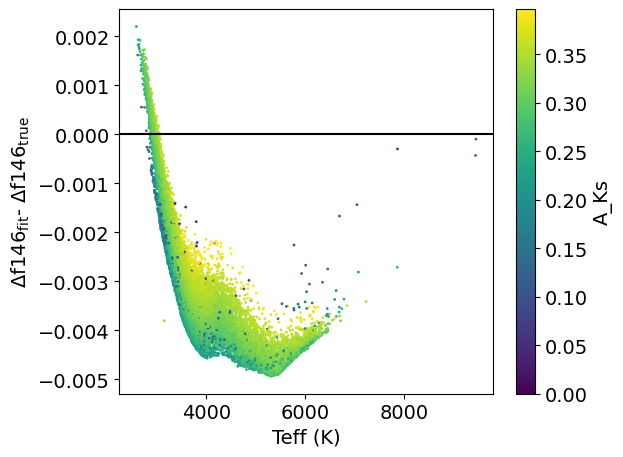

In [56]:
fig = ecf.plot_catalog_results(cat_lb_ext,maglim=25,ext='_lb')

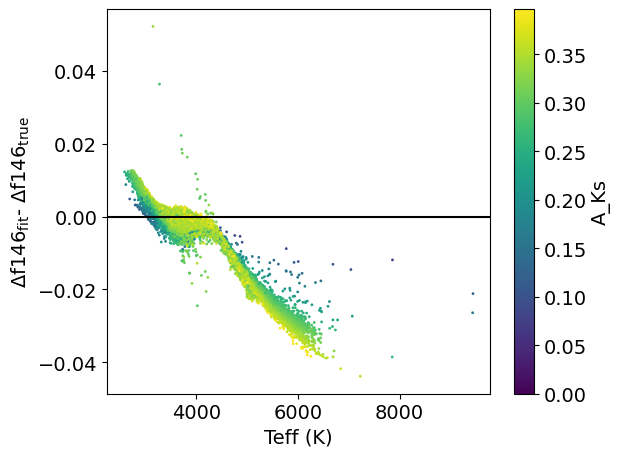

In [57]:
fig = ecf.plot_catalog_results(cat_lb_ext,maglim=25,ext='_lb', use_syn=True)

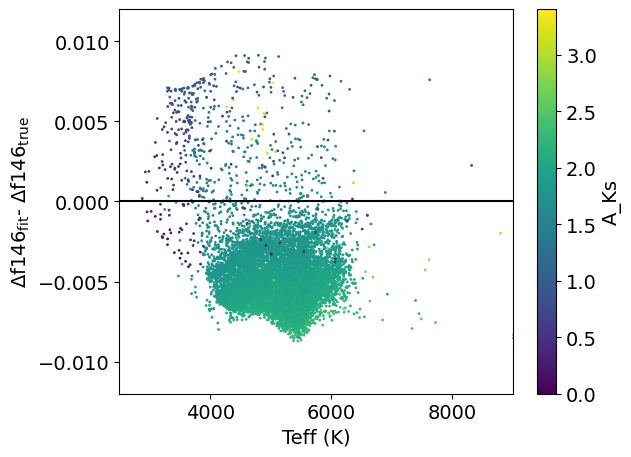

In [58]:
fig = ecf.plot_catalog_results(cat_gc_ext,maglim=25,ext='_gc')
fig.ylim(-0.012,0.012); fig.xlim(2500,9000)
fig.savefig('figures/ext_cat_test_f146_gc.png')

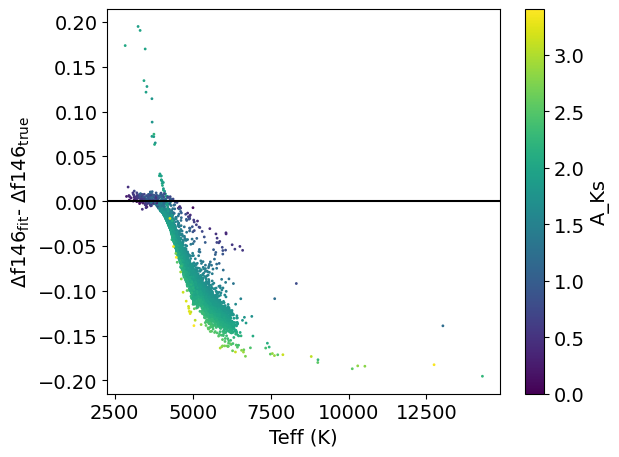

In [59]:
fig = ecf.plot_catalog_results(cat_gc_ext,maglim=25,ext='_gc',use_syn=True)
#fig.ylim(-0.02,0.02)

# Euclid

In [60]:
ecf.run_fit('vis', ['f062_f087_abs'], order=4)

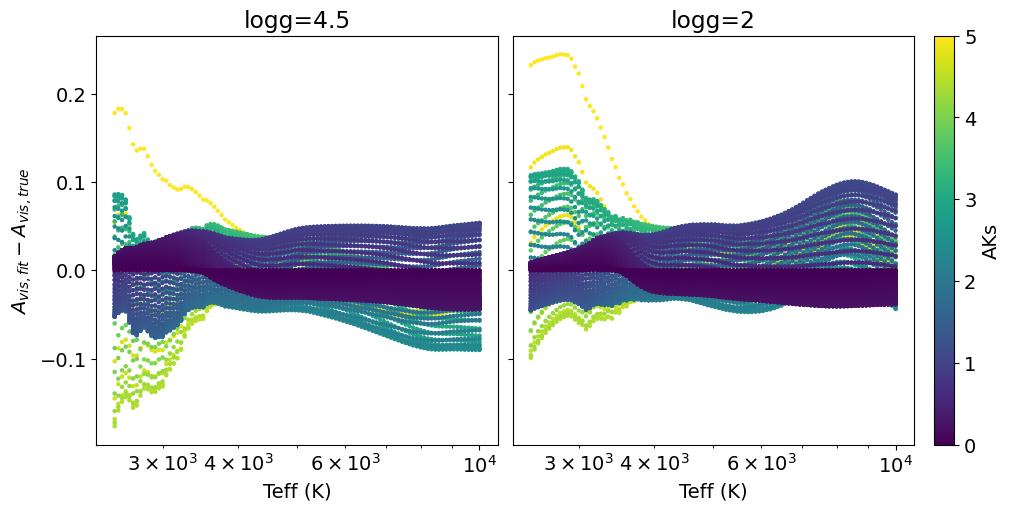

In [61]:
fig,ax = ecf.plot_fit_result()